In [1]:
import os
import pandas as pd

DATA_DIR = os.getcwd()

corners = pd.read_csv(os.path.join(DATA_DIR, 'corners_data.csv'))
prices = pd.read_csv(os.path.join(DATA_DIR, 'corners_prices.csv'))
results = pd.read_csv(os.path.join(DATA_DIR, 'corners_prices_results.csv'))

display(corners.head(3))
display(prices.head(3))
display(results.head(3))

,match_id,home_team_id,away_team_id,competition_id,season_id,date_time,gameweek,home_ft_score,away_ft_score,home_corners,away_corners
0,8826964,3162,3185,524,188160,2023-04-22 16:00:00,31,0,1,3.0,4.0
1,8823251,702,690,795,188124,2023-03-11 15:15:00,25,1,1,10.0,3.0
2,8341130,5638,5655,255,187965,2022-05-02 23:00:00,4,2,1,2.0,4.0


,match_id,home_team_id,away_team_id,competition_id,season_id,date_time,gameweek,oh,oa,od,odds_type
0,12449818,1638,1627,346,189951,2025-02-15 15:00:00,33,NaN,NaN,NaN,OU
1,13578813,5650,5653,255,191431,2025-05-05 23:00:00,7,NaN,NaN,NaN,OU
2,12406033,1669,1612,364,189908,2025-01-18 15:00:00,22,1.75,2.05,10.5,OU


,match_id,home_ft_score,away_ft_score,home_corners,away_corners
0,12409670,0,2,4.0,5.0
1,12409748,1,2,2.0,3.0
2,12409691,1,0,5.0,3.0


## Basic checks

In [2]:
corners['date_time'] = pd.to_datetime(corners['date_time'], errors='coerce')
prices['date_time'] = pd.to_datetime(prices['date_time'], errors='coerce')

print('\nColumns with missing values in corners (count > 0):')
print(corners.isna().sum()[corners.isna().sum() > 0])

print('\nColumns with missing values in betting odds:')
print(prices.isna().sum()[prices.isna().sum() > 0])

print('\nColumns with missing values in match results (scores and corners):')
print(results.isna().sum()[results.isna().sum() > 0])

print('\nDuplicate match_id check (rows with same match_id):')
print('corners:', corners['match_id'].duplicated().sum(), '(should be 0)')
print('match results:', results['match_id'].duplicated().sum(), '(should be 0)')

# How many rows of oh, oa, and od are in bidding odds?
print('\nCounts of each odds_type (OU / HC / 1X2):')
print(prices['odds_type'].value_counts(dropna=False))


Columns with missing values in corners (count > 0):
date_time       148
home_corners     12
away_corners     12
dtype: int64

Columns with missing values in betting odds:
date_time      14
oh           1631
oa           1631
od           1631
dtype: int64

Columns with missing values in match results (scores and corners):
home_corners    4
away_corners    4
dtype: int64

Duplicate match_id check (rows with same match_id):
corners: 273 (should be 0)
match results: 0 (should be 0)

Counts of each odds_type (OU / HC / 1X2):
odds_type
OU     2297
1X2    2297
HC      812
Name: count, dtype: int64


## Clean match result tables and the price table

In [3]:
corners = corners.dropna(subset=['date_time', 'home_corners', 'away_corners'])

# 999 is invalid corner count
corners = corners[(corners['home_corners'] != 999) & (corners['away_corners'] != 999)]

# remove duplicate match_id with conflicting scores/corners
cols_to_check = ['home_ft_score', 'away_ft_score', 'home_corners', 'away_corners']

dup = corners[corners['match_id'].duplicated(keep=False)]
bad_corner_ids = []

for mid, g in dup.groupby('match_id'):
    if (g[cols_to_check].nunique() > 1).any():
        bad_corner_ids.append(mid)

corners = corners[~corners['match_id'].isin(bad_corner_ids)]
corners = corners.drop_duplicates()

corners['home_corners'] = corners['home_corners'].astype(int)
corners['away_corners'] = corners['away_corners'].astype(int)
corners['total_corners'] = corners['home_corners'] + corners['away_corners']
corners['corner_diff_home_minus_away'] = corners['home_corners'] - corners['away_corners']


results = results.dropna(subset=['home_corners', 'away_corners'])

# remove duplicate match_id with conflicting scores/corners
dup = results[results['match_id'].duplicated(keep=False)]
bad_result_ids = []

for mid, g in dup.groupby('match_id'):
    if (g[cols_to_check].nunique() > 1).any():
        bad_result_ids.append(mid)

results = results[~results['match_id'].isin(bad_result_ids)]
results = results.drop_duplicates()

results['home_corners'] = results['home_corners'].astype(int)
results['away_corners'] = results['away_corners'].astype(int)
results['total_corners'] = results['home_corners'] + results['away_corners']
results['corner_diff_home_minus_away'] = results['home_corners'] - results['away_corners']


display(corners.describe())
display(results.describe())


prices = prices.drop_duplicates()
# drop rows where date_time could not be parsed (14 rows) — needed for Q2 time-based plots
prices = prices.dropna(subset=['date_time'])

prices_missing_odds = prices[prices[['oh', 'oa', 'od']].isna().any(axis=1)]
prices_with_odds = prices.dropna(subset=['oh', 'oa', 'od'])

# oh and oa must be > 1
prices_with_odds = prices_with_odds[
    (prices_with_odds['oh'] > 1) &
    (prices_with_odds['oa'] > 1) &
    (prices_with_odds['odds_type'].isin(['OU', 'HC', '1X2']))
]

# For OU: od is the line (must be > 0); for 1X2: od is the draw price (must be > 1 as decimal odds)
prices_with_odds = prices_with_odds[
    ((prices_with_odds['odds_type'] == 'OU') & (prices_with_odds['od'] > 0)) |
    ((prices_with_odds['odds_type'] == '1X2') & (prices_with_odds['od'] > 1)) |
    ((prices_with_odds['odds_type'] == 'HC'))
]


,match_id,home_team_id,away_team_id,competition_id,season_id,date_time,gameweek,home_ft_score,away_ft_score,home_corners,away_corners,total_corners,corner_diff_home_minus_away
count,1.119800e+04,11198.000000,11198.000000,11198.000000,11198.000000,11198,11198.000000,11198.000000,11198.000000,11198.000000,11198.000000,11198.000000,11198.000000
mean,8.422277e+06,2972.310055,2973.201197,436.476603,187810.810502,2022-07-15 14:23:33.091623,19.979193,1.483211,1.201465,5.393374,4.445169,9.838543,0.948205
min,6.184845e+06,674.000000,674.000000,255.000000,186243.000000,2020-08-08 22:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-17.000000
25%,7.245992e+06,1627.000000,1627.000000,346.000000,187168.000000,2021-07-03 22:00:00,10.000000,1.000000,0.000000,3.000000,3.000000,7.000000,-2.000000
50%,8.341276e+06,2453.000000,2453.000000,412.000000,187965.000000,2022-07-10 21:30:00,20.000000,1.000000,1.000000,5.000000,4.000000,10.000000,1.000000
75%,9.967584e+06,3776.000000,3776.000000,524.000000,188756.000000,2023-08-13 13:45:00,30.000000,2.000000,2.000000,7.000000,6.000000,12.000000,4.000000
max,1.313984e+07,19830.000000,19830.000000,795.000000,189971.000000,2024-12-08 19:00:00,46.000000,9.000000,8.000000,23.000000,19.000000,26.000000,23.000000
std,1.608572e+06,2311.196172,2312.294653,161.473377,1031.234403,NaN,11.490354,1.266504,1.129290,2.918778,2.606143,3.372449,4.387377


,match_id,home_ft_score,away_ft_score,home_corners,away_corners,total_corners,corner_diff_home_minus_away
count,2.293000e+03,2293.000000,2293.000000,2293.000000,2293.000000,2293.000000,2293.000000
mean,1.252795e+07,1.484082,1.230702,5.372002,4.368949,9.740951,1.003053
std,2.226483e+05,1.264129,1.136603,2.981303,2.597645,3.350271,4.477449
min,1.240586e+07,0.000000,0.000000,0.000000,0.000000,1.000000,-17.000000
25%,1.241223e+07,1.000000,0.000000,3.000000,3.000000,7.000000,-2.000000
50%,1.245000e+07,1.000000,1.000000,5.000000,4.000000,10.000000,1.000000
75%,1.262329e+07,2.000000,2.000000,7.000000,6.000000,12.000000,4.000000
max,1.381925e+07,8.000000,6.000000,18.000000,18.000000,23.000000,17.000000


## Build the Q2 betting evaluation set

Use an inner join because Q2 needs both prices and realised corner results.

In [4]:
betting = prices_with_odds.merge(
    results[['match_id', 'home_ft_score', 'away_ft_score', 'home_corners', 'away_corners', 'total_corners', 'corner_diff_home_minus_away']],
    on='match_id',
    how='inner',
    suffixes=('', '_result')
)

display(betting.head(3))

# Compare the distribution of corners in the betting dataset vs corners_data
# As one will be used for training and the other for testing, we want to check if they have similar distributions 
betting_matches = betting.drop_duplicates('match_id')

# Compare corner count summary
corner_cols = ['home_corners', 'away_corners', 'total_corners']

summary = pd.concat([
    corners[corner_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
        .add_prefix('corners_data_'),
    betting_matches[corner_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
        .add_prefix('betting_')
], axis=1)

display(summary)

,match_id,home_team_id,away_team_id,competition_id,season_id,date_time,gameweek,oh,oa,od,odds_type,home_ft_score,away_ft_score,home_corners,away_corners,total_corners,corner_diff_home_minus_away
0,12406033,1669,1612,364,189908,2025-01-18 15:00:00,22,1.75,2.05,10.5,OU,0,2,2,16,18,-14
1,12623171,2462,2444,426,189970,2024-10-06 15:30:00,6,1.84,1.98,2.5,HC,3,3,0,11,11,-11
2,12623827,3191,3161,524,189973,2025-01-12 14:00:00,20,1.93,1.89,3.5,HC,0,1,4,5,9,-1


,corners_data_mean,corners_data_std,corners_data_min,corners_data_25%,corners_data_50%,corners_data_75%,corners_data_max,betting_mean,betting_std,betting_min,betting_25%,betting_50%,betting_75%,betting_max
home_corners,5.393374,2.918778,0.0,3.0,5.0,7.0,23.0,5.289377,2.991172,0.0,3.0,5.0,7.0,18.0
away_corners,4.445169,2.606143,0.0,3.0,4.0,6.0,19.0,4.380952,2.610156,0.0,2.0,4.0,6.0,16.0
total_corners,9.838543,3.372449,0.0,7.0,10.0,12.0,26.0,9.670330,3.348385,1.0,7.0,10.0,12.0,21.0


## Train vs betting distribution check

This decides whether `corners_data.csv` is representative enough for the later betting task.

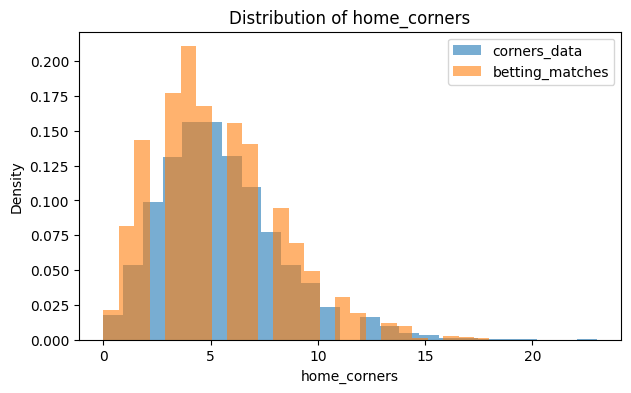

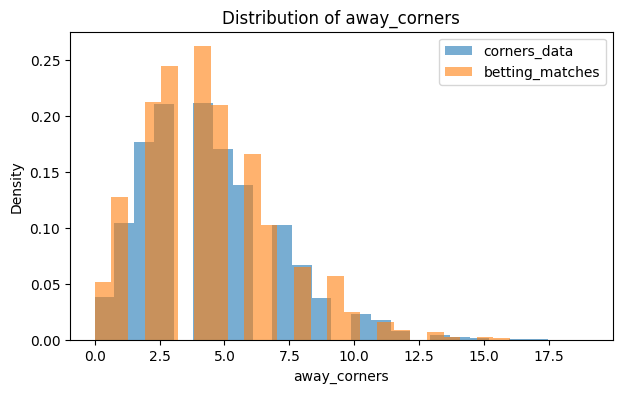

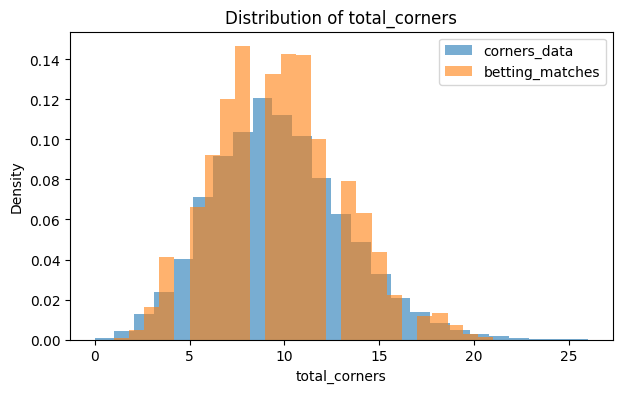

,corners_data,betting_matches
competition_id,,
255,0.156546,0.030874
346,0.198785,0.110937
364,0.135739,0.186813
412,0.129130,0.152800
426,0.108502,0.152800
524,0.135560,0.184720
795,0.135739,0.181057


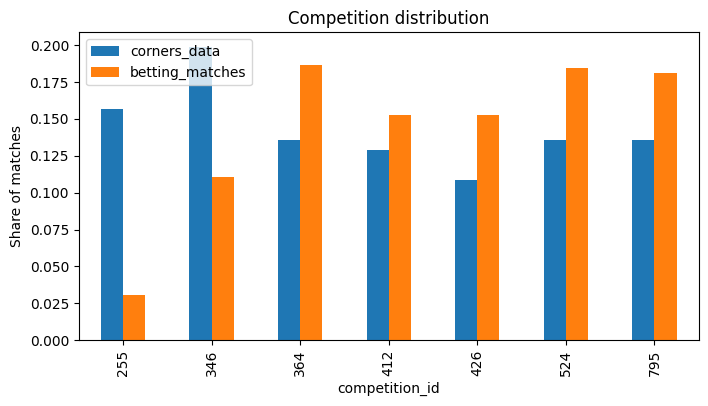

,corners_data,betting_matches
season_id,,
186243,0.033935,0.000000
186265,0.027237,0.000000
186267,0.033935,0.000000
186333,0.049652,0.000000
186353,0.033756,0.000000
186667,0.031077,0.000000
186810,0.033935,0.000000
187168,0.030720,0.000000
187374,0.033935,0.000000


In [5]:
# Visual comparison of corner distributions
import matplotlib.pyplot as plt

for col in ['home_corners', 'away_corners', 'total_corners']:
    plt.figure(figsize=(7, 4))
    plt.hist(corners[col], bins=25, density=True, alpha=0.6, label='corners_data')
    plt.hist(betting_matches[col], bins=25, density=True, alpha=0.6, label='betting_matches')
    plt.xlabel(col)
    
    plt.ylabel('Density')
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()


# Competition distribution
competition_dist = pd.concat([
    corners['competition_id'].value_counts(normalize=True).rename('corners_data'),
    betting_matches['competition_id'].value_counts(normalize=True).rename('betting_matches')
], axis=1).fillna(0).sort_index()

display(competition_dist)

competition_dist.plot(kind='bar', figsize=(8, 4))
plt.ylabel('Share of matches')
plt.title('Competition distribution')
plt.show()

# Season distribution
season_dist = pd.concat([
    corners['season_id'].value_counts(normalize=True).rename('corners_data'),
    betting_matches['season_id'].value_counts(normalize=True).rename('betting_matches')
], axis=1).fillna(0).sort_index()

display(season_dist)


# Importance Weighting

Reweight train by competition share to match betting distribution, 
then re-visualise corner densities.

In [6]:
import numpy as np
import pandas as pd

# =========================
# Train data
# =========================
train = corners.copy()

# =========================
# Compute competition distributions
# =========================
train_comp = train["competition_id"].value_counts(normalize=True)
betting_comp = betting_matches["competition_id"].value_counts(normalize=True)

# =========================
# Importance weights
# =========================
def get_weight(c):
    return betting_comp.get(c, 0) / train_comp.get(c, 1e-9)

train["iw"] = train["competition_id"].map(get_weight)
train["iw"] = train["iw"] / train["iw"].mean()

# =========================
# Mean comparison
# =========================
cols = ["home_corners", "away_corners", "total_corners"]

for col in cols:
    mask = train[col].notna()

    original_mean   = train[col].mean()
    reweighted_mean = np.average(train.loc[mask, col], weights=train.loc[mask, "iw"])
    betting_mean    = betting_matches[col].mean()

    print(f"\n{col}")
    print("original mean:", round(original_mean, 4))
    print("reweighted mean:", round(reweighted_mean, 4))
    print("betting mean    :", round(betting_mean, 4))


home_corners
original mean: 5.3934
reweighted mean: 5.3218
betting mean    : 5.2894

away_corners
original mean: 4.4452
reweighted mean: 4.3996
betting mean    : 4.381

total_corners
original mean: 9.8385
reweighted mean: 9.7214
betting mean    : 9.6703


In [7]:

corners["match_id"].duplicated().sum()
print("duplicates in corners:", corners["match_id"].duplicated().sum())

dupes = corners[corners.duplicated(subset="match_id", keep=False)]
dupes = dupes.sort_values("match_id")
print("Number of duplicated rows:", len(dupes))
display(dupes)

overlap = set(corners["match_id"]) & set(results["match_id"])
print("overlap:", len(overlap))

duplicates in corners: 0
Number of duplicated rows: 0


,match_id,home_team_id,away_team_id,competition_id,season_id,date_time,gameweek,home_ft_score,away_ft_score,home_corners,away_corners,total_corners,corner_diff_home_minus_away


overlap: 0


In [8]:
for col in ['home_corners', 'away_corners']:
    m, v = corners[col].mean(), corners[col].var()
    print(f"{col}: mean={m:.2f}, var={v:.2f}, ratio={v/m:.2f}")

# train: corners_data with importance weights — used for model training (Q1)
# betting: prices + realised results — used for Q2 EV/PnL evaluation
train.to_parquet('train.parquet', index=False)
betting.to_parquet('betting.parquet', index=False)
print("Saved train.parquet:", train.shape, "| betting.parquet:", betting.shape)


home_corners: mean=5.39, var=8.52, ratio=1.58
away_corners: mean=4.45, var=6.79, ratio=1.53
Saved train.parquet: (11198, 14) | betting.parquet: (3758, 17)


## Build the unified outcomes table for Stage 1a

`betting.parquet` only contains the **1911 matches that have valid odds
AND realised results** (inner-join). It silently drops 386 matches that
have outcomes in `corners_prices_results.csv` but no usable odds in
`corners_prices.csv`. As a side effect, 7 teams that appear only in the
prices universe — 712, 1622, 1683, 2495, 2496, 3200, 6032 — have many
of their historical outcomes invisible to any pipeline that builds
features from `corners_data + betting.parquet`.

For team-strength estimation we want **every match with an observed
corner outcome**, regardless of whether prices were sold. Build
`all_matches.parquet` as the union of:

- `corners` — the cleaned historical pool (training universe).
- `results` — Q2-period match outcomes, enriched with team metadata
  pulled from `prices` (date, team_ids, competition_id, season_id,
  gameweek). Outcomes alone don't carry these columns; we recover them
  by joining one row per match_id from `prices`.

Drop duplicates on `match_id`. Save with the schema Q1's Stage 1a
expects: `match_id, date_time, home_team_id, away_team_id,
competition_id, season_id, gameweek, home_ft_score, away_ft_score,
home_corners, away_corners`.

In [9]:
cols = ['match_id', 'date_time', 'home_team_id', 'away_team_id',
        'competition_id', 'season_id', 'gameweek',
        'home_ft_score', 'away_ft_score', 'home_corners', 'away_corners']

prices_meta = (prices.drop_duplicates('match_id')
               [['match_id', 'home_team_id', 'away_team_id',
                 'competition_id', 'season_id', 'date_time', 'gameweek']])
results_enriched = results.merge(prices_meta, on='match_id', how='left')

all_matches = pd.concat([corners[cols], results_enriched[cols]], ignore_index=True)

# Drop rows whose team metadata couldn't be recovered (results-only entries
# without a matching prices row — unusable for team-strength updates).
n_orphan = all_matches[['home_team_id', 'away_team_id', 'date_time']].isna().any(axis=1).sum()
all_matches = all_matches.dropna(subset=['home_team_id', 'away_team_id', 'date_time'])

all_matches = (all_matches.drop_duplicates('match_id')
                          .sort_values('date_time')
                          .reset_index(drop=True))

for c in ['home_team_id', 'away_team_id', 'competition_id', 'season_id', 'gameweek']:
    all_matches[c] = all_matches[c].astype('int64')

teams_in_corners  = set(corners['home_team_id']) | set(corners['away_team_id'])
teams_in_all      = set(all_matches['home_team_id']) | set(all_matches['away_team_id'])
recovered_teams   = teams_in_all - teams_in_corners

all_matches.to_parquet('all_matches.parquet', index=False)
print(f'Saved all_matches.parquet: {all_matches.shape}  (dropped {n_orphan} orphan rows without team metadata)')
print(f'date range: {all_matches.date_time.min().date()} to {all_matches.date_time.max().date()}')
print(f'teams: {len(teams_in_all)}  (corners_data alone: {len(teams_in_corners)};  recovered: {len(recovered_teams)})')
print(f'recovered team_ids: {sorted(recovered_teams)}')
print(f'team 1683 matches in unified table: '
      f"{((all_matches.home_team_id==1683)|(all_matches.away_team_id==1683)).sum()}")

Saved all_matches.parquet: (13484, 11)  (dropped 7 orphan rows without team metadata)
date range: 2020-08-08 to 2025-05-12
teams: 187  (corners_data alone: 180;  recovered: 7)
recovered team_ids: [712, 1622, 1683, 2495, 2496, 3200, 6032]
team 1683 matches in unified table: 46
